(700, 478)


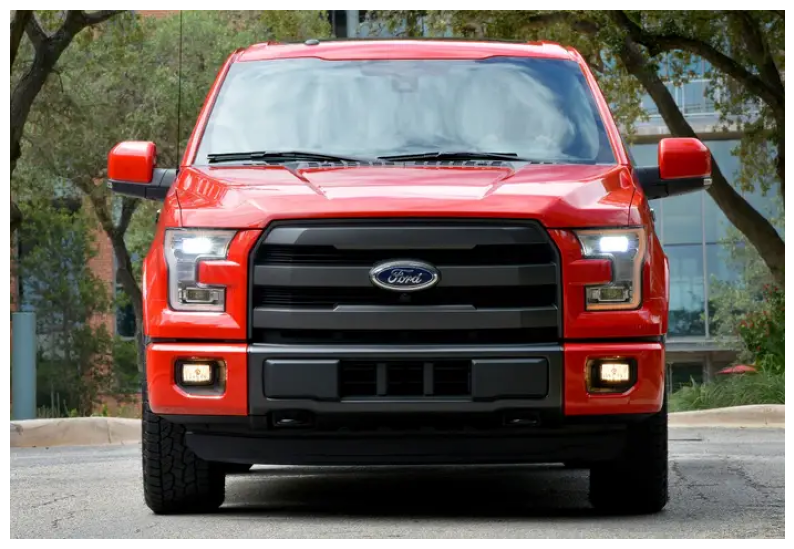

In [57]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T


img_path = "truck.jpeg"

img = Image.open(img_path).convert("RGB")
print(img.size)

plt. figure(figsize=(10, 10))
plt.imshow(img)
plt.axis("off")
plt.show()


In [58]:
transform = T.ToTensor()
x = transform(img).unsqueeze(0)  # add batch dimension

print("Tensor shape:", x.shape)

Tensor shape: torch.Size([1, 3, 478, 700])


In [59]:
kernel = torch.zeros(1, 3, 3, 3)

kernel[0, 0] = torch.tensor([[1, 2, 1],
                             [2, -12, 2],
                             [1, 2, 1]])

kernel[0, 1] = kernel[0, 0]

kernel[0, 2] = kernel[0, 0]

print("Kernel shape:", kernel.shape)
print(kernel[0, 1])

Kernel shape: torch.Size([1, 3, 3, 3])
tensor([[  1.,   2.,   1.],
        [  2., -12.,   2.],
        [  1.,   2.,   1.]])


In [60]:
y = F.conv2d(x, kernel, stride=1, padding=1)
print("Output shape:", y.shape)

Output shape: torch.Size([1, 1, 478, 700])


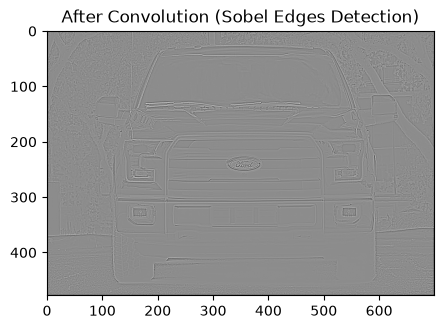

In [ ]:
out = y.squeeze().detach().numpy()

plt.figure(figsize=(5,5))
plt.title("After Convolution )")
plt.imshow(out, cmap="gray");

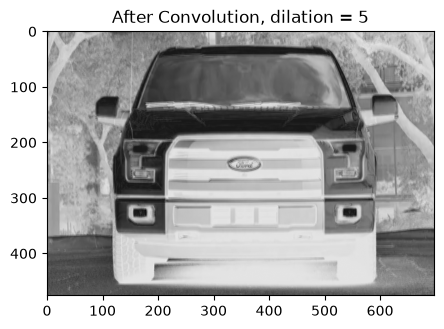

In [62]:
torch.manual_seed(0)
depthwise_kernel = torch.randn(3, 1, 3, 3)  # 3 input channels, separate filter each

y_depthwise = F.conv2d(x, depthwise_kernel, groups=3)

out = y_depthwise.squeeze().detach().numpy()
plt.figure(figsize=(5,5))
plt.title("After Convolution, dilation = 5")
plt.imshow(out[0, :, :], cmap="gray");